In [2]:
from colossus.cosmology import cosmology
from colossus.lss import peaks
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import scipy.stats as sts
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
from sim_read import *

plt.rcParams["axes.linewidth"]  = 2
plt.rcParams["xtick.major.size"]  = 8
plt.rcParams["xtick.minor.size"]  = 3
plt.rcParams["ytick.major.size"]  = 8
plt.rcParams["ytick.minor.size"]  = 3
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams.update({'font.size': 24})
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams["mathtext.default"] = 'rm'
plt.rcParams["mathtext.fontset"] = 'cm'



In [3]:
cosmo = cosmology.setCosmology('planck15')
Om = cosmo.Om0
h0 = cosmo.H0/100

dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

In [4]:
gls = sim(exgrp_fields=['GroupFirstSub','Group_M_Mean200','Group_R_Mean200'],exsub_fields=['SubhaloMass','SubhaloStellarPhotometrics','SubhaloMassType'])
sim.mass_add(gls)

massive_gal,dwarf_gal = dwf_select(gls.sub.mst,floor=7.5,thresh=9.5)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))


1494 10829


/Users/bhattacharyya.37/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [5]:
import h5py
hf = h5py.File('galaxies_accrates_tng50_099.hdf5', 'r')

print(hf.keys())
catgrp_m200 = np.copy(hf.get('catgrp_Group_M_Mean200'))
all_halos = np.where(catgrp_m200>=1e9)[0]

group_m200 = np.log10(catgrp_m200[all_halos]) 
group_r200 = np.copy(hf.get('catgrp_Group_R_Mean200'))[all_halos]
group_acc = np.copy(hf.get('scalar_acc_rate_10tdyn_200m'))[all_halos]

hf.close()

<KeysViewHDF5 ['catgrp_GroupCM', 'catgrp_GroupMassType', 'catgrp_GroupNsubs', 'catgrp_GroupPos', 'catgrp_GroupVel', 'catgrp_Group_M_Crit200', 'catgrp_Group_M_Crit500', 'catgrp_Group_M_Mean200', 'catgrp_Group_M_TopHat200', 'catgrp_Group_R_Crit200', 'catgrp_Group_R_Crit500', 'catgrp_Group_R_Mean200', 'catgrp_Group_R_TopHat200', 'catgrp_id', 'catgrp_is_primary', 'catsh_SubhaloCM', 'catsh_SubhaloGrNr', 'catsh_SubhaloHalfmassRadType', 'catsh_SubhaloMassInHalfRadType', 'catsh_SubhaloMassInRadType', 'catsh_SubhaloMassType', 'catsh_SubhaloPos', 'catsh_SubhaloSpin', 'catsh_SubhaloVel', 'catsh_SubhaloVmax', 'catsh_id', 'config', 'info', 'scalar_acc_rate_05tdyn_200c', 'scalar_acc_rate_05tdyn_200m', 'scalar_acc_rate_05tdyn_500c', 'scalar_acc_rate_05tdyn_vir', 'scalar_acc_rate_10tdyn_200c', 'scalar_acc_rate_10tdyn_200m', 'scalar_acc_rate_10tdyn_500c', 'scalar_acc_rate_10tdyn_vir', 'tree_Group_M_Crit200', 'tree_Group_M_Mean200', 'tree_is_primary']>


(array([0.00000000e+00, 0.00000000e+00, 5.49664612e+00, 2.59651468e-01,
        3.21360587e-02, 7.95186730e-03, 2.03725526e-03, 6.57179115e-04,
        5.25743292e-04, 1.97153735e-04, 1.31435823e-04, 0.00000000e+00,
        6.57179115e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]),
 array([0.        , 0.17241379, 0.34482759, 0.51724138, 0.68965517,
        0.86206897, 1.03448276, 1.20689655, 1.37931034, 1.55172414,
        1.72413793, 1.89655172, 2.06896552, 2.24137931, 2.4137931 ,
        2.5862069 , 2.75862069, 2.93103448, 3.10344828, 3.27586207,
        3.44827586, 3.62068966, 3.79310345, 3.96551724, 4.13793103,
        4.31034483, 4.48275862, 4.65517241, 4.82758621, 5.        ]),
 [<matplotlib.patches.Polygon at 0x7fadb0be8e50>])

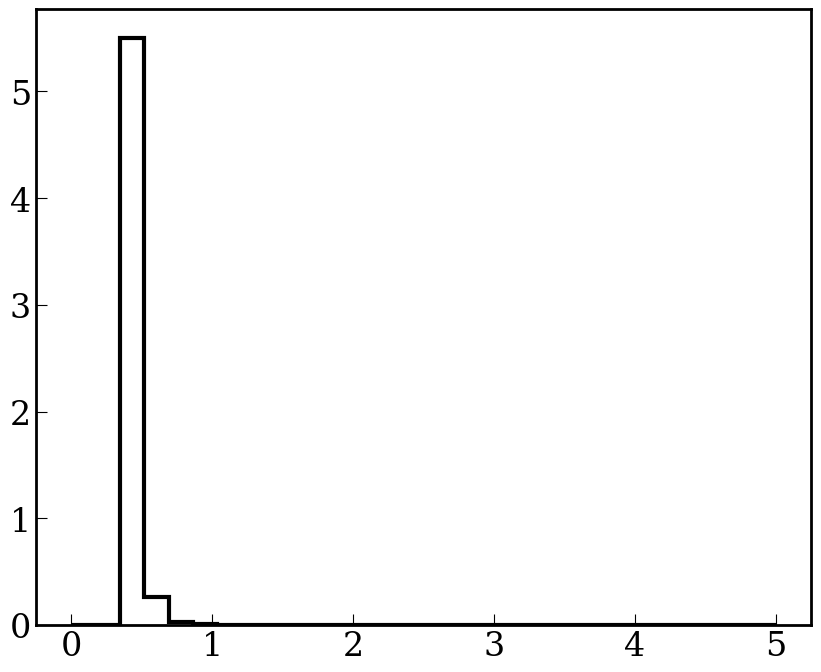

In [27]:
fig,ax=plt.subplots(figsize=(10,8))

ax.hist(peaks.peakHeight(catgrp_m200[all_halos], 0),bins=np.linspace(0,5,30),color='black',histtype='step',lw=3,density=True)


In [19]:
def diemer20_Rsp(Gdyn,nu,A=[0.6597],B=[0.5562,0.1141,0.0698],C=[-0.8508,18.4464,-10.059,-0.3332,0.0474]):
    A=A[0]
    B=(B[0]+B[1]*Om)*(1+B[2]*nu)
    C=(C[0]+C[1]*Om+C[2]*Om*Om)*(1+C[3]*nu+C[4]*nu*nu)
    return A+B*np.exp(-Gdyn/C)

In [28]:

Rsp = diemer20_Rsp(group_acc,peaks.peakHeight(catgrp_m200[all_halos], 0))

In [29]:
def tidal_D(M): return np.power(10,(M-10.96)/3)

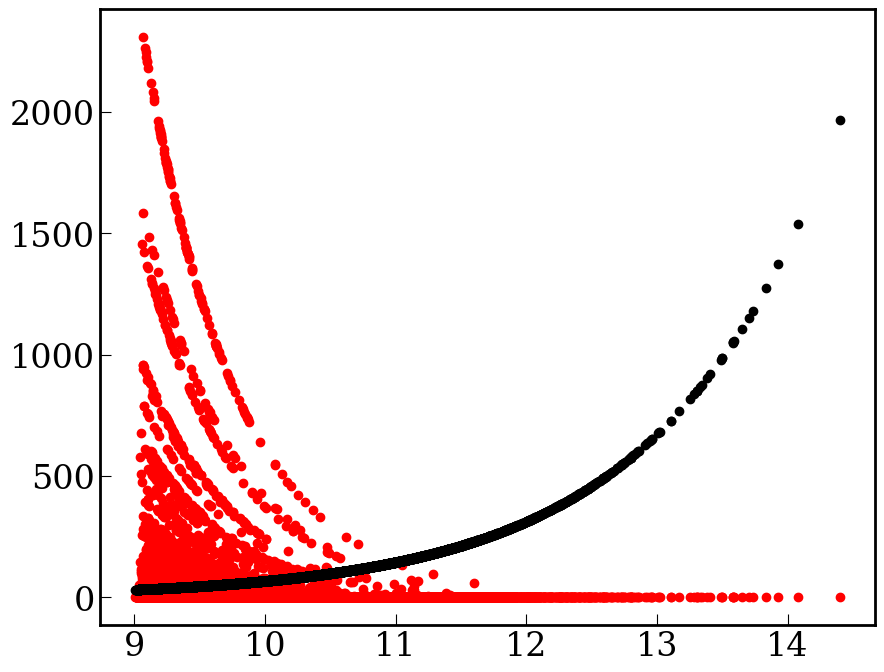

In [30]:
fig,ax=plt.subplots(figsize=(10,8))

ax.scatter(group_m200,Rsp,color='red')
ax.scatter(group_m200,group_r200,color='black')
#ax.plot(group_m200,tidal_D(group_m200),color='black')
'''
ax.set_xlim((10,14))
ax.set_ylim((7.5,11.5))
ax.axhline(9.5,ls=':',lw=1,color='black')
ax.axvline(11.5,ymax=0.5,ls=':',lw=1,color='black')

ax.text(10.25,10.5,r'$Massive\ Galaxies$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(11.75,8,r'$Satellite\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(10.15,8,r'$Field\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
'''
#ax.set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
#ax.set_ylabel(r'$Subhalo\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=26)
ax.set_rasterized(True)
#plt.savefig('hostM_subhaloM.pdf',bbox_inches='tight')

In [ ]:
D_mass = mconv + np.log10(gls.sub.SubhaloMass[ind[1:]])

                dhost[2].append(dist[1])
                llt[2].append(max(MD_mass - 3*np.log10(dist[1:])) - 10.96)